<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/satisfaction.png'/></center>

### **고객 만족도 예측을 통한 서비스 개선**
# **단계 3: 모델 추가 학습**

## **미션 설명**

- 이번 단계에서는 다음과 같이 3개의 미션을 수행합니다.

### 미션 8: 전처리 파이프라인 만들기

- 새로운 학습용/검증용 데이터에 대해 매번 전처리 작업을 수행해야 합니다.
- 반복되는 전처리 작업은 비효율적인 업무 중 하나입니다.
- 이러한 문제를 해결하기 위해 다음과 같은 처리를 일괄 수행하는 파이프라인 함수를 만듭니다.
    - 결측치 처리
    - Target 값 0/1로 변경
    - 불필요한 변수 제거
    - 라벨 인코딩
    - 가변수화
    - x, y 분리
    - x 스케일링 등

### 미션 9: 기본 모델로 예측 및 평가

- 이전 과정에서 만든 모델이 기본 모델(Base Model)입니다.
- 새로 전달 받은 평가용 데이터로 기존에 만든 모델의 성능을 평가해봅니다.

### 미션 10: 추가 학습

- 문제 상황에 맞게 가장 적절한 방법으로 모델 추가 학습을 진행합니다.
- 추가 학습 후 이전에 평가했던 새로운 평가 데이터로 다시 평가해 성능 향상을 확인합니다.

## **※ 코드 셀은 충분히 추가해 사용합니다.**

## **1. 환경설정**

### (1) 구글 드라이브 연결 및 경로 설정

- 다음 구문을 실행에 구글 코랩에서 사용 가능하게 연결합니다.

In [1]:
# 구글 드라이브 연결 & 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/project01/'
else:
    path = ''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### (2) 라이브러리 불러오기

- 이후에 사용할 라이브러리를 모두 불러옵니다.

In [2]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import *

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.backend import clear_session
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (3) 학습 곡선 시각화 함수 만들기

- 모델링 수행 시 학습 상황을 시각화해 확인하기 위한 함수를 만듭니다.

In [3]:
# 함수 만들기
def dl_history_plot(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history['loss'], label='Train Loss', marker='.')
    plt.plot(history['val_loss'], label='Validation Loss', marker='.')

    plt.title('Learning Curve', size=15, pad=20)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

### (4) 기본 모델 및 데이터 불러오기

- 우선 이전 과정에서 저장한 모델을 불러와 base_model로 선언합니다.
    - path + 'base_model.keras' →  base_model
- **load_model()** 함수를 사용합니다.


In [4]:
# 모델 불러오기
base_model = load_model(path + 'base_model.keras')

- 이전 과정에서 저장한 스케일러를 불러와 scaler 변수에 저장합니다.
    - path + 'scaler.pkl' →  scaler
- **joblib.load()** 함수를 사용합니다.

In [5]:
# 스케일러 불러오기
scaler = joblib.load(path + 'scaler.pkl')

- 이전 과정에서 저장한 파일을 읽어와 new_test, new_train 데이터프레임을 만듭니다.
    - path + 'new_test.csv' → new_test
    - path + 'new_train.csv' → new_train

In [6]:
# 파일 불러오기
new_test = pd.read_csv(path + 'new_test.csv')
new_train = pd.read_csv(path + 'new_train.csv')

In [7]:
new_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         350 non-null    int64  
 1   ID                                 350 non-null    int64  
 2   Gender                             350 non-null    object 
 3   Customer Type                      350 non-null    object 
 4   Age                                340 non-null    float64
 5   Type of Travel                     350 non-null    object 
 6   Class                              350 non-null    object 
 7   Flight Distance                    350 non-null    int64  
 8   Inflight wifi service              335 non-null    float64
 9   Departure/Arrival time convenient  350 non-null    int64  
 10  Ease of Online booking             350 non-null    int64  
 11  Gate location                      350 non-null    int64  

## **2. 미션 8: 전처리 파이프라인 만들기**

- 다음 과정을 일괄 처리한 후 x, y를 반환하는 함수를 만듭니다.
    - 결측치 처리
    - Target 값 0/1로 변경
    - 불필요한 변수 제거
    - 라벨 인코딩
    - 가변수화
    - x, y 분리
    - x 스케일링 등
- 함수 이름은 **build_model_input** 로 지정합니다.
- 다음과 같이 사용할 수 있어야 합니다.
    - 예1) x_val, y_val = build_model_input(new_test)
    - 예2) x_trian, y_train = build_model_input(new_train)


In [8]:
# 함수 만들기
def build_model_input(data):

    # 1. 결측치 처리

    # 1-1) 수치형 변수 선택
    num_cols = data.select_dtypes(include=['number']).columns

    # 1-1) 결측치 → 중앙값
    for col in num_cols:
      median_val = data[col].median()             # 수치형 변수들의 중앙값 처리
      data[col].fillna(median_val, inplace=True)  # 결측치들을 중앙값으로 채우고 덮어씌우기

    # 1-2) 범주형 변수 선택
    cat_cols = data.select_dtypes(include=['object', 'category']).columns

    # 1-2) 결측치 → 최빈값
    for col in cat_cols:
      mod_val = data[col].mode()               # 범주형 변수들의 최빈값 처리
      data[col].fillna(mod_val, inplace=True)  # 결측치들을 최빈값으로 채우고 덮어씌우기


    # 2. 값 변경
    target = 'Satisfaction'
    # .strip()을 추가해 혹시 모를 앞뒤 공백을 제거하고 매핑합니다.
    data[target] = data[target].str.strip().map({'Satisfied': 1, 'Neutral or Dissatisfied': 0})

    # 2-1. 매핑 후 혹시 생겼을지 모를 NaN 행 제거 (평가를 위해)
    data.dropna(subset=[target], inplace=True)


    # 3. 변수 제거
    # 불필요한 변수 제거 및 이미 없어도 에러 안나게
    drop_cols = ['Unnamed: 0', 'ID']
    data = data.drop(columns=[c for c in drop_cols if c in data.columns], axis=1)


    # 4. 라벨 인코딩
    cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

    for col in cat_cols:
        if col in data.columns: # data(입력받은 변수)를 사용
            encoder = LabelEncoder()
            # new_train이 아니라 data[col]에 결과를 담아야 함
            data[col] = encoder.fit_transform(data[col])


    # 5. 가변수화
    # 설문 범주 정의
    categories = [0, 1, 2, 3, 4, 5]

    # 가변수화 대상 변수
    dumm_cols = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location',
                'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service',
                'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']

    # 5-1) Category 형 변수로 변환
    for col in dumm_cols:
        data[col] = pd.Categorical(data[col], categories=categories)

    # 5-2) 가변수화
    data = pd.get_dummies(data, columns=dumm_cols, drop_first=True, dtype=int)
    # drop_first 옵션이 첫번재 0(해당없음)을 없애준것


    # 6. x, y 분리
    target = 'Satisfaction'
    x = data.drop(target, axis=1)
    y = data.loc[:, target]


    # 7. 스케일링
    # 미리 불러온 scaler 객체를 사용 (MinMaxScaler())
    x_scaled = scaler.transform(x)
    x = pd.DataFrame(x_scaled, columns=x.columns)


    # 반환
    return x, y

- 점검: 다음 구문이 잘 수행되어 x_val, y_val이 분리되어야 합니다.


## **3. 미션 9: 기본 모델로 예측 및 평가**

### (1) 데이터 전처리

- new_test 데이터프레임을 x_val, y_val로 분리합니다.

In [9]:
# x_val, y_val 나누기
x_val, y_val = build_model_input(new_test)

# 확인
print(x_val.shape)
print(y_val.shape)

(350, 78)
(350,)


### (2) 예측 및 평가

- 새로운 데이터에 대한 예측과 평가를 수행합니다.

In [10]:
# 예측 (확률값 반환)
y_pred = base_model.predict(x_val)

# 이진 분류로 변환 (0.5기준)
y_pred = np.where(y_pred >= 0.5, 1, 0)

# 성능 평가
print("="*40)
print("   [ Base Model Evaluation ]")
print("="*40)
print(f"Accuracy  : {accuracy_score(y_val, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_val, y_pred):.4f}")
print("-" * 40)
print("Classification Report:")
print(classification_report(y_val, y_pred))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
   [ Base Model Evaluation ]
Accuracy  : 0.9400
F1-Score  : 0.9366
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.91      0.94       191
           1       0.90      0.97      0.94       159

    accuracy                           0.94       350
   macro avg       0.94      0.94      0.94       350
weighted avg       0.94      0.94      0.94       350



## **4. 미션 10: 모델 추가 학습**

### (1) 학습용 데이터 준비

- new_train 데이터프레임을 x_train, y_train으로 분리합니다.

In [11]:
# x_train, y_train 나누기
x_train, y_train = build_model_input(new_train)

# 확인
print(x_train.shape)
print(y_train.shape)

(850, 78)
(850,)


### (2) 방법 1: 모델 초기화

- 이전에 만들었던 성능이 좋았던 모델과 같은 모델을 만들어 학습 후 성능을 확인합니다.

In [12]:
# 메모리 정리
clear_session()

# 입력 Feature 수
nfeatures = x_train.shape[1]

# Sequential 모델 선언
my_model = Sequential([
    Input(shape=(nfeatures, )),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# 모델 요약
my_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,481 (80.00 KB)

 Trainable params: 20,481 (80.00 KB)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [13]:
# 학습 설정
my_model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', min_delta=0.01, patience=7, restore_best_weights=True, verbose=1)

# 학습
# 1. 클래스 가중치 설정 (불만족 0에 10배 중요도 부여)
class_weights = {0: 10.0, 1: 1.0}

# 2. 모델 학습 (검증 데이터와 가중치 통합)
hist = my_model.fit(x_train, y_train,
                 epochs=50,
                 batch_size=64,                   # 곡선을 매끄럽게 하기 위해 64 추천
                 validation_data=(x_val, y_val),  # 분리해둔 검증셋 사용
                 class_weight=class_weights,      # 불균형 해소를 위한 가중치 적용
                 verbose=1)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 555ms/step - accuracy: 0.5271 - loss: 3.3600 - val_accuracy: 0.5457 - val_loss: 0.7112
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5494 - loss: 2.1493 - val_accuracy: 0.5457 - val_loss: 0.8646
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5447 - loss: 1.6346 - val_accuracy: 0.5457 - val_loss: 1.0497
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5447 - loss: 1.5765 - val_accuracy: 0.5457 - val_loss: 1.0790
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5447 - loss: 1.4453 - val_accuracy: 0.5457 - val_loss: 0.9896
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5447 - loss: 1.3267 - val_accuracy: 0.5457 - val_loss: 0.9234
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5447 - loss: 1.2946 - val_accuracy: 0.5457 - val_loss: 0.8696
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5459 - loss: 1.2452 - val_accuracy: 0.5457 -

- 학습 곡선을 확인합니다.

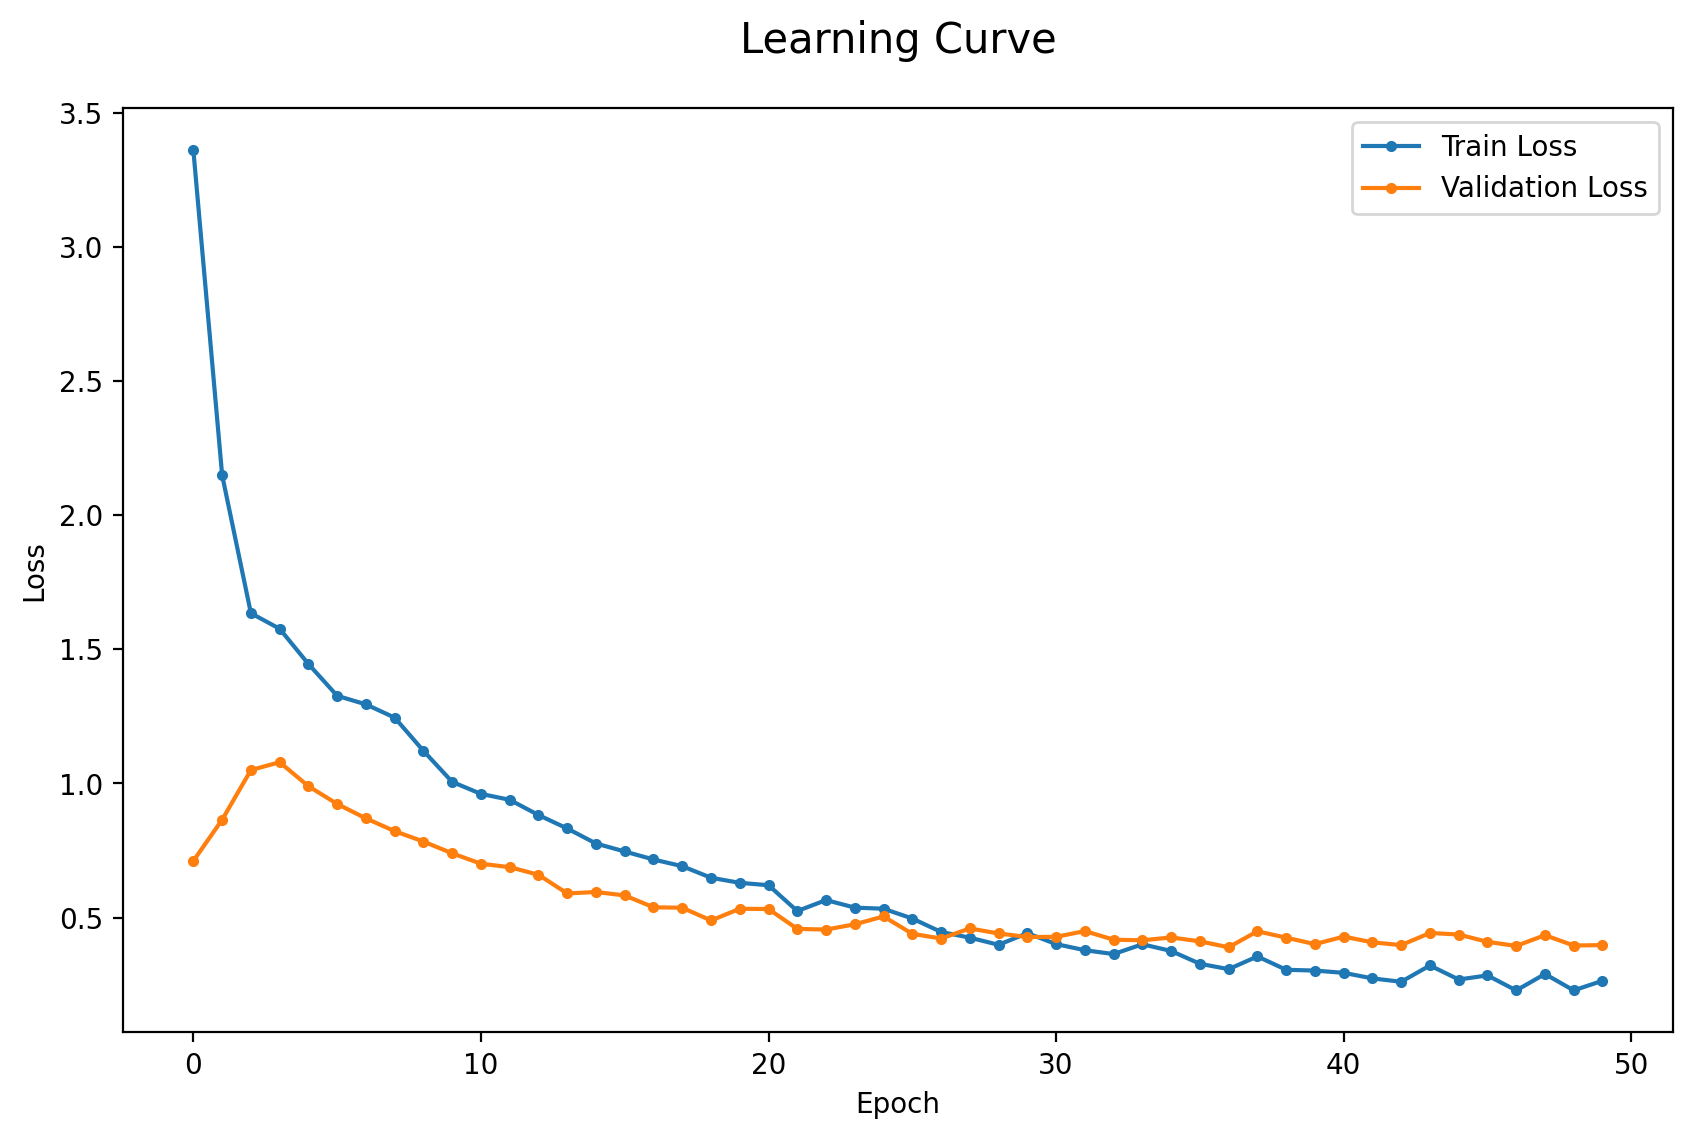

In [14]:
dl_history_plot(hist.history)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [18]:
# 예측
y_pred = my_model.predict(x_val)

# 이진 분류로 변환 (0.5기준)
y_pred = np.where(y_pred >= 0.5, 1, 0)

# 성능 평가
print("="*40)
print("   [ my_model Evaluation ]")
print("="*40)
print(f"Accuracy  : {accuracy_score(y_val, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_val, y_pred):.4f}")
print("-" * 40)
print("Classification Report:")
print(classification_report(y_val, y_pred))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
   [ my_model Evaluation ]
Accuracy  : 0.8971
F1-Score  : 0.8784
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       191
           1       0.95      0.82      0.88       159

    accuracy                           0.90       350
   macro avg       0.91      0.89      0.89       350
weighted avg       0.90      0.90      0.90       350



 [ new_train (학습 데이터) ]
Satisfaction
0    54.470588
1    45.529412
Name: proportion, dtype: float64
------------------------------
 [ new_test (테스트 데이터) ]
Satisfaction
0    54.571429
1    45.428571
Name: proportion, dtype: float64


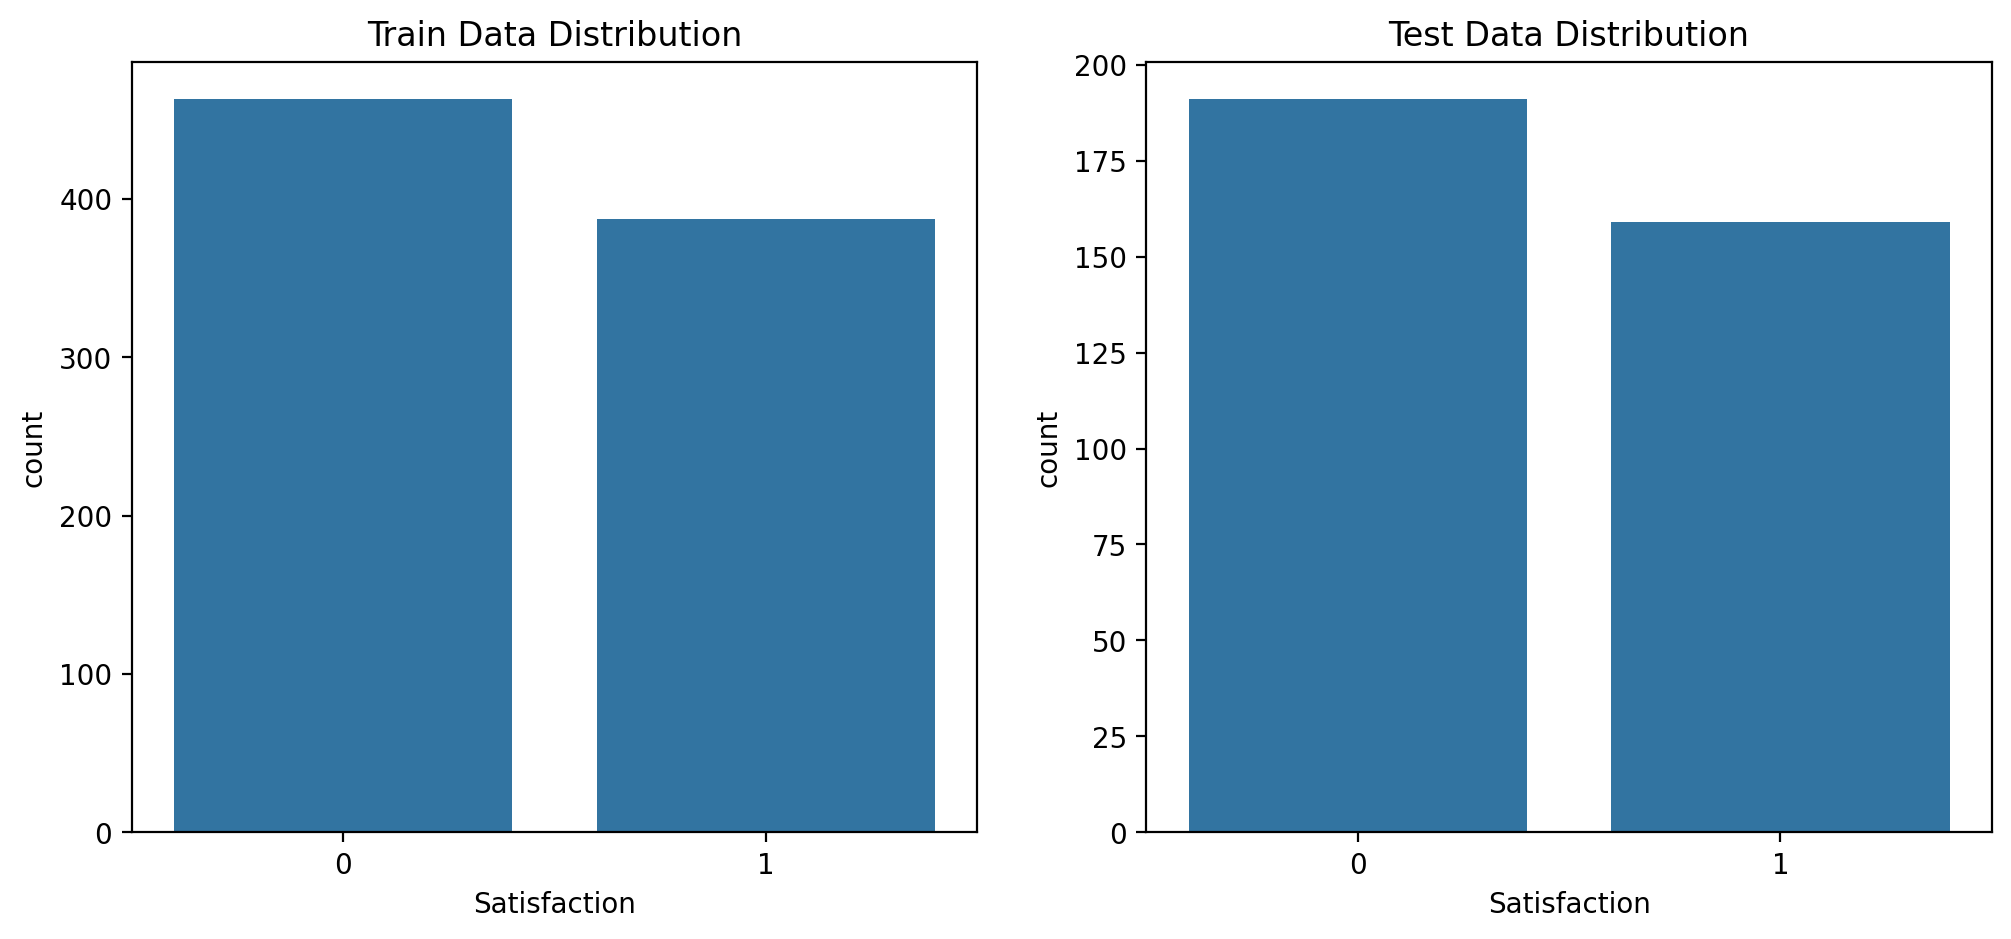

In [20]:
# 두 데이터의 비율을 비교하기 위한 코드
print(" [ new_train (학습 데이터) ]")
print(new_train['Satisfaction'].value_counts(normalize=True) * 100)
print("-" * 30)

print(" [ new_test (테스트 데이터) ]")
print(new_test['Satisfaction'].value_counts(normalize=True) * 100)

# 시각화로 한눈에 비교하기
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Satisfaction', data=new_train)
plt.title('Train Data Distribution')

plt.subplot(1, 2, 2)
sns.countplot(x='Satisfaction', data=new_test)
plt.title('Test Data Distribution')

plt.show()

### (3) 방법 2: 추가 학습

- 기본 모델을 기반으로 모델을 선언하고 추가 학습 후 성능을 확인합니다.

- 학습 방법을 설정하고 학습을 수행합니다.

- 학습 곡선을 확인합니다.

- 검증 데이터로 예측 및 평가를 수행합니다.

### (4) 방법 3: 미세조정

- 기본 모델의 앞쪽 레이어 일부의 학습 기능을 비활성화합니다.
- 기본 모델을 기반으로 레이어를 추가한 모델을 선언합니다.
- 추가 학습을 진행한 뒤 성능을 확인합니다.

In [ ]:
# 모델 불러오기
base_model = load_model(path + 'base_model.keras')

# 마지막 레이어 제거
base_model.pop()

- 학습 방법을 설정하고 학습을 수행합니다.

- 학습 곡선을 확인합니다.

- 검증 데이터로 예측 및 평가를 수행합니다.